# Урок 5.2. Алгоритм Фридмана (GBM/TreeBoost) по строчкам

**Интерактивная версия:** `lessons/lesson_5_2/web/index.html`

1. TreeBoost своими руками для любой функции потерь.
2. Сверка с gbcourse и scikit-learn (L1 и квантильные потери).
3. Эффект линейного поиска: среднее псевдо-остатков против оптимальных γ.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from gbcourse import datasets, RegressionTree, GBRegressor, get_loss
from gbcourse.plotting import use_course_style

use_course_style()

## 1. TreeBoost своими руками

Строки алгоритма подписаны в комментариях.

In [2]:
def tree_boost(X, y, loss, M=200, nu=0.1, depth=2, line_search=True):
    F = np.full(len(y), loss.init(y))                       # 1. F0 = argmin_ρ Σ L(y, ρ)
    f0, trees = F[0], []
    for _ in range(M):                                      # 2.
        r = loss.negative_gradient(y, F)                    # 3. псевдо-остатки
        tree = RegressionTree(max_depth=depth).fit(X, -r)   # 4. дерево по наименьшим квадратам
        if line_search:                                     # 5'. γ_jm для каждого листа
            for leaf in tree.leaves:
                leaf.value = loss.leaf_value(y[leaf.rows], F[leaf.rows])
            tree.refresh_values()
        F = F + nu * tree.predict(X)                        # 6. F_m = F_{m−1} + ν Σ γ_jm 1(x ∈ R_jm)
        trees.append(tree)
    return f0, trees


def predict(f0, trees, X, nu=0.1):
    return f0 + nu * sum(t.predict(X) for t in trees)


X, y = datasets.regression_1d(kind="wave", n=300, noise=0.3, seed=53, outliers=0.1)
X_tr, X_te, y_tr, y_te = datasets.train_test_split(X, y, test_size=0.3, seed=0)

## 2. Сверка

In [3]:
for name, kw in [("absolute", {}), ("quantile", {"alpha": 0.8}), ("huber", {"delta": 1.0})]:
    loss = get_loss(name, **kw)
    f0, trees = tree_boost(X_tr, y_tr, loss)
    ours = predict(f0, trees, X_te)
    lib = GBRegressor(loss=name, quantile_alpha=kw.get("alpha", 0.5), huber_delta=kw.get("delta", 1.0),
                      n_estimators=200, learning_rate=0.1, max_depth=2).fit(X_tr, y_tr).predict(X_te)
    print(f"{name:9s}: наш TreeBoost − gbcourse = {np.abs(ours - lib).max():.2e}")

sk = GradientBoostingRegressor(loss="absolute_error", n_estimators=200, learning_rate=0.1, max_depth=2).fit(X_tr, y_tr)
f0, trees = tree_boost(X_tr, y_tr, get_loss("absolute"))
print("L1: MAE теста sklearn", np.mean(np.abs(y_te - sk.predict(X_te))).round(4),
      "| наш", np.mean(np.abs(y_te - predict(f0, trees, X_te))).round(4))

absolute : наш TreeBoost − gbcourse = 1.33e-15
quantile : наш TreeBoost − gbcourse = 2.66e-15
huber    : наш TreeBoost − gbcourse = 1.78e-15


L1: MAE теста sklearn 0.815 | наш 0.8122


С scikit-learn для L1 результат близок, но не бит-в-бит: sklearn считает медиану как взвешенный
перцентиль (для чётного числа объектов берёт нижнюю медиану, а не среднее двух центральных).

## 3. Что даёт линейный поиск

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


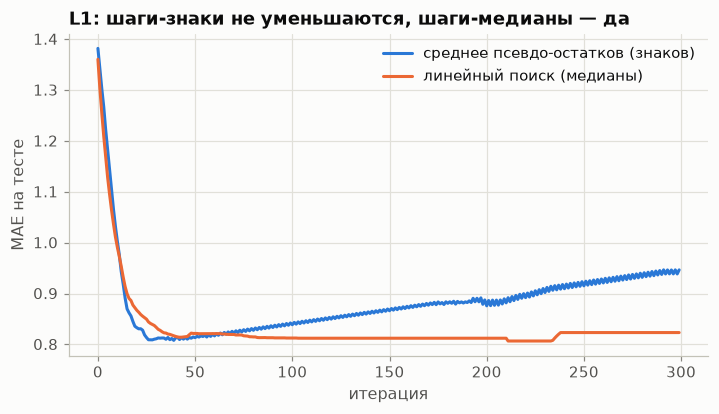

In [4]:
fig, ax = plt.subplots(figsize=(7.5, 3.8))
for ls in (False, True):
    loss = get_loss("absolute")
    f0, trees = tree_boost(X_tr, y_tr, loss, M=300, line_search=ls)
    curve, F = [], np.full(len(y_te), f0)
    for t in trees:
        F = F + 0.1 * t.predict(X_te)
        curve.append(np.mean(np.abs(y_te - F)))
    ax.plot(curve, label="линейный поиск (медианы)" if ls else "среднее псевдо-остатков (знаков)")
ax.set(xlabel="итерация", ylabel="MAE на тесте", title="L1: шаги-знаки не уменьшаются, шаги-медианы — да")
ax.legend()
plt.show()

Вначале варианты почти равны, но дальше они расходятся. Листья-«средние знаков» ограничены
диапазоном [−1, 1] и не уменьшаются, когда остатки становятся малыми: модель продолжает делать
шаги фиксированного размера, «дребезжит» и подгоняется под шум — как градиентный спуск по |θ|
в уроке 1.3. Медианы остатков уменьшаются вместе с самими остатками, и качество стабилизируется.

## Упражнения

1. Реализуйте Gradient_Boost с **одним** шагом $\rho_m$ на дерево (строка 5 алгоритма 1) для L1 и сравните с TreeBoost.
2. Выведите оптимальный $\gamma$ листа для потерь Пуассона $L = e^F - yF$.
3. Почему значение листа Хьюбера у Фридмана — лишь приближение оптимума? Найдите оптимум численно и сравните.

Решения: `python lessons/lesson_5_2/exercises/solutions.py`.